In [81]:
!pip install fair-esm matplotlib tqdm

In [82]:
import torch
import esm

esm_model, alphabet = esm.pretrained.esm2_t6_8M_UR50D()
esm_model.eval()

batch_converter = alphabet.get_batch_converter()

In [83]:
def get_embedding(seq):
    data = [("protein", seq)]
    _, _, tokens = batch_converter(data)

    with torch.no_grad():
        out = esm_model(tokens, repr_layers=[6])

    return out["representations"][6][0]

In [84]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("hazemessam/fireprot_db")
df = dataset['train'].to_pandas()

df = df[['sequence', 'position', 'wild_type', 'mutation', 'ddG']].dropna()

df['pos'] = df['position'] - 1
df = df[df.apply(lambda r: r['sequence'][r['pos']] == r['wild_type'], axis=1)]

In [85]:
df_small = df.sample(200, random_state=42).reset_index(drop=True)

In [86]:
X = np.array(X)
y = np.array(y)

In [87]:
import numpy as np
from tqdm import tqdm
import torch

X = []
y = []

amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

for _, row in tqdm(df_small.iterrows(), total=len(df_small)):
    seq = row['sequence']
    pos = int(row['pos'])
    mut = row['mutation']
    ddg = row['ddG']

    wt_embed = get_embedding(seq)

    wt_vec = wt_embed[pos + 1]

    # FAST mutation simulation
    aa_index = amino_acids.index(mut)
    mut_vec = wt_vec.clone()
    mut_vec[aa_index % wt_vec.shape[0]] += 0.1

    feature = torch.cat([
        wt_vec,
        mut_vec,
        wt_vec - mut_vec,
        torch.abs(wt_vec - mut_vec)
    ])

    X.append(feature.numpy())
    y.append(ddg)

X = np.array(X)
y = np.array(y)

100%|██████████| 200/200 [00:53<00:00,  3.72it/s]


In [88]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [89]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [90]:
import torch.nn as nn

class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.4),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)

In [91]:
import torch

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)

model_nn = MLP(X.shape[1])

optimizer = torch.optim.Adam(
    model_nn.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)

loss_fn = nn.MSELoss()

for epoch in range(300):
    model_nn.train()

    preds = model_nn(X_train_t)
    loss = loss_fn(preds, y_train_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(epoch, loss.item())

0 3.528881549835205
50 0.09616250544786453
100 0.06227421015501022
150 0.04379434511065483
200 0.05013379454612732
250 0.039231546223163605


In [92]:
from scipy.stats import pearsonr

model_nn.eval()
with torch.no_grad():
    preds = model_nn(X_test_t).numpy().flatten()

corr, _ = pearsonr(y_test, preds)
print("Test Pearson:", corr)

Test Pearson: 0.6414512890806714


In [93]:
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, preds))
print("RMSE:", rmse)

RMSE: 1.0791740370447662


In [95]:
import numpy as np
from tqdm import tqdm
import torch

sequence = "MALWMRLLPLLALLALWGPDPAAAFVNQHLCGSHLVEALYLVCGERGFFYTPKT"
amino_acids = list("ACDEFGHIKLMNPQRSTVWY")
L = len(sequence)

heatmap = np.zeros((20, L))

wt_embed = get_embedding(sequence)

model_nn.eval()

for i, aa in enumerate(amino_acids):
    for pos in tqdm(range(L)):
        if sequence[pos] == aa:
            continue
        mut_seq = list(sequence)
        mut_seq[pos] = aa
        mut_seq = "".join(mut_seq)

        mut_embed = get_embedding(mut_seq)

        wt_vec = wt_embed[pos + 1]
        mut_vec = mut_embed[pos + 1]

        feature = torch.cat([
            wt_vec,
            mut_vec,
            wt_vec - mut_vec,
            torch.abs(wt_vec - mut_vec)
        ]).numpy().reshape(1, -1)

        feature_scaled = scaler.transform(feature)

        with torch.no_grad():
            pred = model_nn(torch.tensor(feature_scaled, dtype=torch.float32))

        heatmap[i, pos] = pred.item()

100%|██████████| 54/54 [00:01<00:00, 35.03it/s]


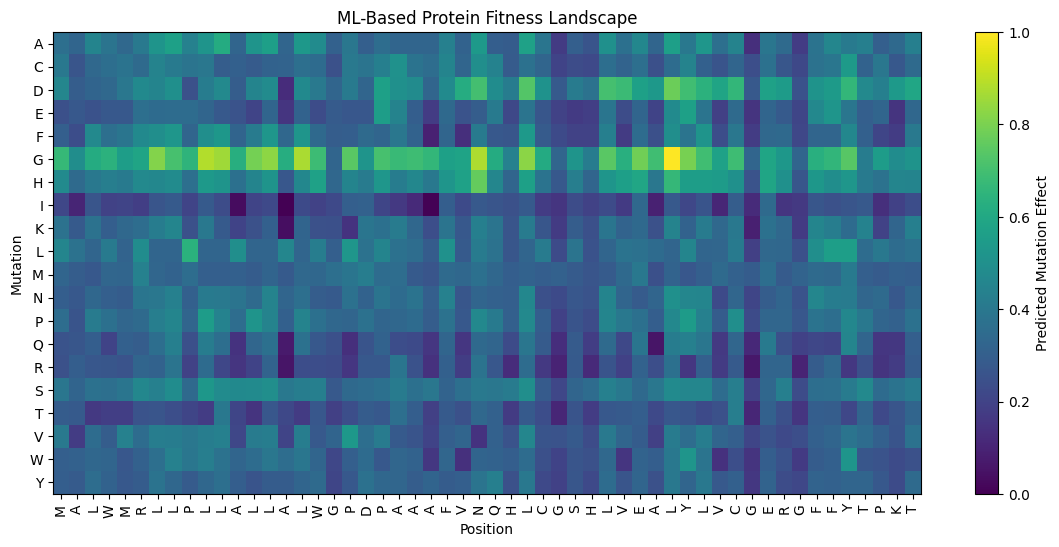

In [96]:
import matplotlib.pyplot as plt

# Normalize for visualization
heatmap_norm = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min())

plt.figure(figsize=(14, 6))
plt.imshow(heatmap_norm, aspect='auto', cmap='viridis')
plt.colorbar(label="Predicted Mutation Effect")
plt.yticks(range(20), amino_acids)
plt.xticks(range(L), list(sequence), rotation=90)
plt.xlabel("Position")
plt.ylabel("Mutation")
plt.title("ML-Based Protein Fitness Landscape")
plt.show()

In [97]:
position_scores = heatmap.mean(axis=0)
important_positions = np.argsort(position_scores)[-5:]
print("Most sensitive positions:", important_positions)

top_mutations = []
for i, aa in enumerate(amino_acids):
    for pos in range(L):
        top_mutations.append((heatmap[i, pos], pos, sequence[pos], aa))

top_mutations = sorted(top_mutations, reverse=True)[:10]
for score, pos, wt, mut in top_mutations:
    print(f"{wt}{pos+1}{mut} → {score:.3f}")

Most sensitive positions: [39 49 26 29 38]
L39G → 4.613
L10G → 3.829
N27G → 3.771
L16G → 3.747
L11G → 3.628
L14G → 3.445
L30G → 3.417
L7G → 3.343
Y40G → 3.221
L13G → 3.189


In [99]:
!pip install py3Dmol biopython

In [100]:
import py3Dmol
import requests

pdb_id = "3I40"  # insulin
url = f"https://files.rcsb.org/download/{pdb_id}.pdb"

pdb_data = requests.get(url).text

In [101]:
position_scores = heatmap.mean(axis=0)

scores = (position_scores - position_scores.min()) / (
    position_scores.max() - position_scores.min()
)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

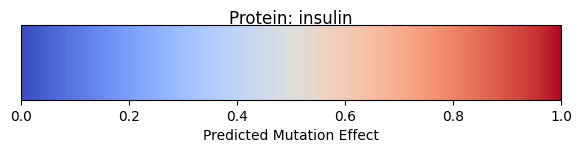

In [120]:
import matplotlib.cm as cm
import matplotlib as mpl

pdb_id = "3I40"  # insulin
url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
pdb_data = requests.get(url).text

position_scores = heatmap.mean(axis=0)
scores = (position_scores - position_scores.min()) / (position_scores.max() - position_scores.min())

cmap = plt.get_cmap('coolwarm')
view = py3Dmol.view(width=800, height=500)
view.addModel(pdb_data, "pdb")
view.setStyle({}, {})  # hide everything first

# Color surface per residue
for i, score in enumerate(scores):
    r, g, b, _ = cmap(score)
    color = f"rgb({int(r*255)},{int(g*255)},{int(b*255)})"
    view.addSurface(py3Dmol.SAS, {"opacity":1.0, "color": color}, {"resi":i+1})

view.zoomTo()
view.show()

import matplotlib.pyplot as plt
import matplotlib as mpl

# Colormap and normalization
cmap = plt.get_cmap('coolwarm')
norm = mpl.colors.Normalize(vmin=0, vmax=1)

# Create figure
fig = plt.figure(figsize=(6, 1.5))  # Slightly taller to fit label

# Add an axes for the colorbar (full figure)
cax = fig.add_axes([0.05, 0.3, 0.9, 0.5])  # [left, bottom, width, height]
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

# Draw colorbar
cbar = plt.colorbar(sm, cax=cax, orientation='horizontal')
cbar.set_label("Predicted Mutation Effect", fontsize=10)

# Add title above
fig.suptitle("Protein: insulin", fontsize=12, y=0.9)

plt.show()


In [121]:
print("Residues sensitive to mutation")

high_positions = np.argsort(position_scores)[-5:]

for pos in high_positions:
    print(f"Position {pos+1} ({sequence[pos]}) is highly sensitive to mutation")

Residues sensitive to mutation
Position 40 (Y) is highly sensitive to mutation
Position 50 (Y) is highly sensitive to mutation
Position 27 (N) is highly sensitive to mutation
Position 30 (L) is highly sensitive to mutation
Position 39 (L) is highly sensitive to mutation


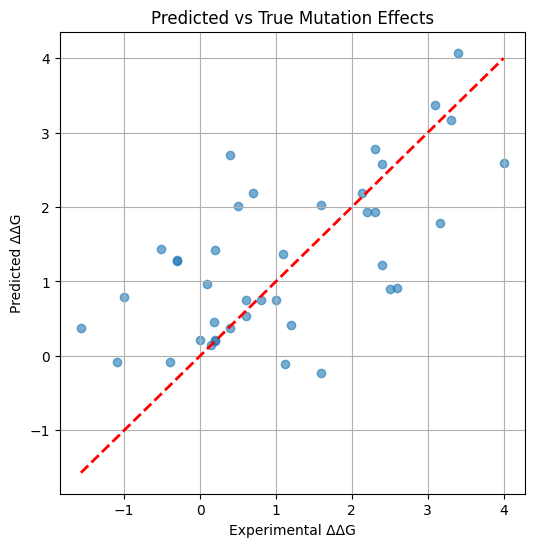

In [104]:
import matplotlib.pyplot as plt

model_nn.eval()
with torch.no_grad():
    preds = model_nn(torch.tensor(X_test, dtype=torch.float32)).numpy().flatten()

plt.figure(figsize=(6,6))
plt.scatter(y_test, preds, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--', lw=2)
plt.xlabel("Experimental ΔΔG")
plt.ylabel("Predicted ΔΔG")
plt.title("Predicted vs True Mutation Effects")
plt.grid(True)
plt.show()

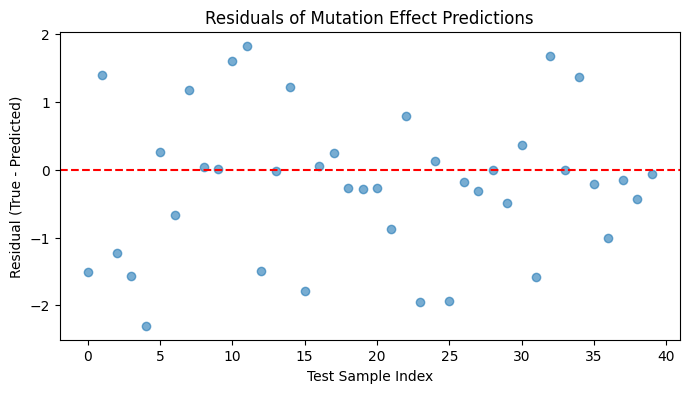

In [105]:
residuals = y_test - preds

plt.figure(figsize=(8,4))
plt.scatter(range(len(residuals)), residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Test Sample Index")
plt.ylabel("Residual (True - Predicted)")
plt.title("Residuals of Mutation Effect Predictions")
plt.show()

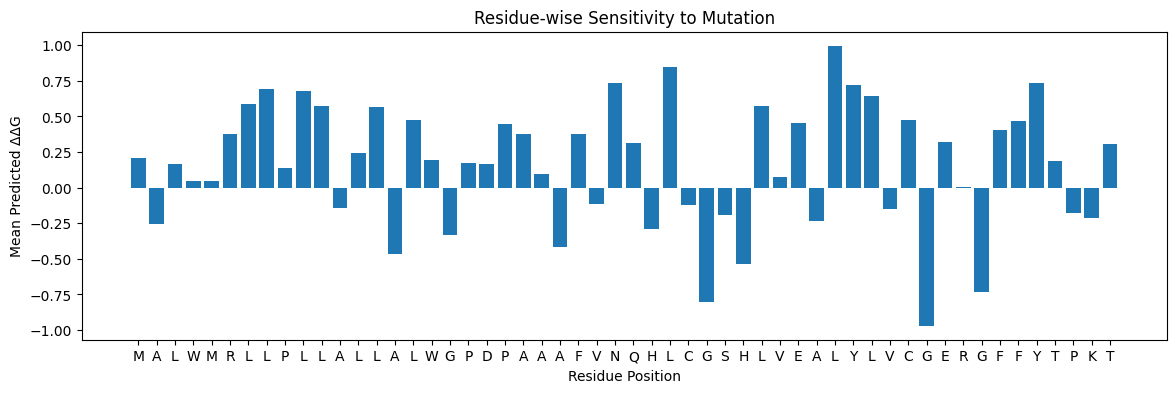

In [107]:
position_scores = heatmap.mean(axis=0)

plt.figure(figsize=(14,4))
plt.bar(range(1, len(sequence)+1), position_scores)
plt.xticks(range(1, len(sequence)+1), list(sequence))
plt.xlabel("Residue Position")
plt.ylabel("Mean Predicted ΔΔG")
plt.title("Residue-wise Sensitivity to Mutation")
plt.show()